# Dipole Antenna Mesh with PalaceToolkit

This notebook uses PalaceToolkit utilities with a robust workflow:
- build primitives
- fragment once for conformal topology
- define `Entity` objects from fragmented geometry
- run `run_meshing_pipeline`, then `generate_3d_mesh`
- visualize with `palacetoolkit.viz`


In [1]:
from pathlib import Path
import math
import gmsh

from palacetoolkit.geometry import xmin, xmax, ymin, ymax, zmin, zmax, extract_tag
from palacetoolkit.mesh import Entity, run_meshing_pipeline, generate_3d_mesh
from palacetoolkit.viz import run_with_scrollable_output, view_mesh

In [2]:
wavelength = 4.0
arm_length = wavelength / 4
arm_radius = arm_length / 20
gap_size = arm_length / 100
outer_boundary_radius = 1.5 * wavelength
mesh_file = "dipole.msh"

In [3]:
gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 2)
gmsh.model.add("dipole_entity_pipeline")
occ = gmsh.model.occ

air = occ.addSphere(0, 0, 0, outer_boundary_radius)
top_arm = occ.addCylinder(0, 0, gap_size / 2, 0, 0, arm_length, arm_radius)
bot_arm = occ.addCylinder(0, 0, -gap_size / 2, 0, 0, -arm_length, arm_radius)
port_sheet = occ.addRectangle(-arm_radius, -gap_size / 2, 0, 2 * arm_radius, gap_size)
occ.rotate([(2, port_sheet)], 0, 0, 0, 1, 0, 0, math.pi / 2)

# Explicit fragment first for conformal interfaces.
occ.fragment([(3, air)], [(3, top_arm), (3, bot_arm), (2, port_sheet)])
occ.synchronize()

all_2d = occ.getEntities(2)
all_3d = occ.getEntities(3)

def spans_outer(dt):
    return math.isclose(xmin(dt), -outer_boundary_radius, abs_tol=outer_boundary_radius / 100)

air_domain = [x for x in all_3d if spans_outer(x)]
top_surfs = [x for x in all_2d if zmin(x) > 0 and not spans_outer(x)]
bot_surfs = [x for x in all_2d if zmax(x) < 0 and not spans_outer(x)]

eps = gap_size / 100
port_surfs = [
    x for x in all_2d
    if math.isclose(xmin(x), -arm_radius, abs_tol=eps)
    and math.isclose(xmax(x), arm_radius, abs_tol=eps)
    and math.isclose(ymin(x), 0, abs_tol=eps)
    and math.isclose(ymax(x), 0, abs_tol=eps)
    and math.isclose(zmin(x), -gap_size / 2, abs_tol=eps)
    and math.isclose(zmax(x), gap_size / 2, abs_tol=eps)
]

# Entity + boolean pipeline for named 2D groups.
entities = [
    Entity("top_arm", dim=2, mesh_order=0, tags=[extract_tag(x) for x in top_surfs]),
    Entity("bot_arm", dim=2, mesh_order=0, tags=[extract_tag(x) for x in bot_surfs]),
    Entity("port", dim=2, mesh_order=0, tags=[extract_tag(x) for x in port_surfs]),
]
pg_map = run_meshing_pipeline(entities)
pg_map["air"] = gmsh.model.addPhysicalGroup(3, [extract_tag(x) for x in air_domain], name="air")

# Stable mesh sizing path for this dipole topology.
gmsh.model.mesh.setSize(gmsh.model.getEntities(0), wavelength / 5)
for ent_name, lc in [("top_arm", arm_radius / 3), ("bot_arm", arm_radius / 3), ("port", gap_size / 2)]:
    dt = []
    for e in entities:
        if e.name == ent_name:
            dt = e.dimtags
            break
    b = gmsh.model.getBoundary(dt, combined=False, oriented=False, recursive=True)
    gmsh.model.mesh.setSize([(d, t) for d, t in b if d == 0], lc)

def _generate_dipole_mesh():
    gmsh.model.mesh.generate(3)
    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.write(mesh_file)
    gmsh.finalize()
    return pg_map

pg_map = run_with_scrollable_output(_generate_dipole_mesh, title="Dipole mesh generation", max_lines=10)
pg_map


  Physical group 'top_arm' (dim=2): pg=1, tags=[14, 15, 16, 17]
  Physical group 'bot_arm' (dim=2): pg=2, tags=[10, 11, 12, 13]
  Physical group 'port' (dim=2): pg=3, tags=[8]


{'top_arm': 1, 'bot_arm': 2, 'port': 3, 'air': 4}

Loading mesh file: dipole.msh
Groups to render transparent: ['air']



Mesh loaded successfully with 2 cell blocks
Found 20474 triangles total
Physical group tags in mesh: {1: 'top_arm', 2: 'bot_arm', 3: 'port'}


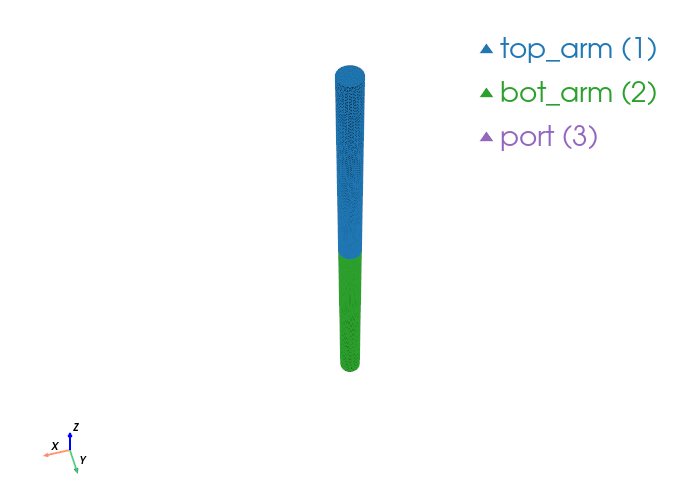

In [4]:
view_mesh(mesh_file, transparent_groups=["air"])